<a href="https://colab.research.google.com/github/fabricejumel/5IRC-2026-2027-CYBER-SIA/blob/main/Attaques_yolov8_PGD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ Laboratoire d'Attaques Adversariales sur YOLOv8 : Projected Gradient Descent (PGD)

### 🎯 Objectif de la Section
Après avoir validé l'attaque en un seul pas (FGSM), nous passons au standard de référence des attaques adversariales : la méthode itérative **PGD (*Projected Gradient Descent*)**.

L'objectif est d'explorer une attaque beaucoup plus agressive et méthodique pour un même budget de perturbation ($\epsilon$) :
1. **Raffinement itératif :** Remplacer le grand saut unique de FGSM par une succession de micro-ajustements guidés par le gradient avec un pas $\alpha$ réduit.
2. **Projection géométrique :** Contraindre à chaque itération le tenseur résultant dans la sphère de perturbation $L_\infty$ autorisée ($[-\epsilon, +\epsilon]$) pour maintenir l'attaque invisible à l'œil humain.
3. **Analyse comparative de rupture :** Confronter directement l'image originale, l'attaque FGSM et l'attaque PGD afin d'observer comment l'optimisation itérative dégrade plus sévèrement les ancres et les scores de confiance de YOLOv8.

*Hypothèse à valider :* À budget d'intensité $\epsilon$ équivalent, l'optimisation multi-étapes de PGD contournera plus efficacement les mécanismes de détection de YOLOv8 que l'approximation linéaire en un coup de FGSM.

In [3]:
# 📦 Installation des dépendances nécessaires (si exécuté sur Google Colab)
!pip install -q ultralytics ipywidgets

# 📚 Importations des bibliothèques
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import cv2
import glob
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML
from ultralytics import YOLO
from ultralytics.utils.downloads import download

from torchvision import transforms

# Pipeline de prétraitement des images pour YOLOv8
preprocess = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor(),
])

# ⚙️ Configuration du matériel (GPU / CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Environnement prêt. Utilisation du périphérique : {device}")

# 🤖 Chargement du modèle YOLOv8 pré-entraîné (modèle léger nano)
model = YOLO("yolov8n.pt")
model.to(device)

# 📂 Téléchargement et préparation du jeu de données COCO8
download("https://ultralytics.com/assets/coco8.zip", dir="./datasets")

# Récupération sécurisée de 8 images de test
image_paths = sorted(glob.glob("./datasets/coco8/**/*.jpg", recursive=True))
if len(image_paths) < 8:
    image_paths = (image_paths * ((8 // len(image_paths)) + 1))[:8]
else:
    image_paths = image_paths[:8]

print(f"✅ {len(image_paths)} images de test chargées avec succès.")

🚀 Environnement prêt. Utilisation du périphérique : cpu
WARNING ⚠️ Skipping datasets/coco8.zip unzip as destination path /content/datasets/coco8 already exists.
✅ 8 images de test chargées avec succès.


In [6]:
def fgsm_attack_yolo(model, image_path, epsilon=0.05):
    raw_image = Image.open(image_path).convert("RGB")
    original_size = raw_image.size

    input_tensor = preprocess(raw_image).unsqueeze(0).to(device)
    input_tensor.requires_grad = True

    # Passage dans le modèle brut
    preds = model.model(input_tensor)

    # Extraction sécurisée d'un tenseur exploitable pour le gradient (selon la structure renvoyée)
    if isinstance(preds, dict):
        # Si c'est un dictionnaire, on prend la première valeur tensorielle trouvée
        target_tensor = next(v for v in preds.values() if isinstance(v, torch.Tensor))
    elif isinstance(preds, (list, tuple)):
        target_tensor = preds[0] if isinstance(preds[0], torch.Tensor) else preds[0][0]
    else:
        target_tensor = preds

    # Loss orientée sur le tenseur extrait
    loss = -torch.mean(torch.abs(target_tensor))

    model.zero_grad()
    loss.backward()

    data_grad = input_tensor.grad.data
    perturbed_image = input_tensor + epsilon * data_grad.sign()
    perturbed_image = torch.clamp(perturbed_image, 0, 1)

    to_pil = transforms.ToPILImage()
    adv_img_pil = to_pil(perturbed_image.squeeze(0).cpu())
    adv_img_pil = adv_img_pil.resize(original_size)

    return adv_img_pil

In [4]:
def pgd_attack_yolo(model, image_path, epsilon=0.05, alpha=0.01, num_iter=10):
    raw_image = Image.open(image_path).convert("RGB")
    original_size = raw_image.size

    orig_tensor = preprocess(raw_image).unsqueeze(0).to(device)
    adv_tensor = orig_tensor.clone().detach()

    for _ in range(num_iter):
        adv_tensor.requires_grad = True

        preds = model.model(adv_tensor)

        if isinstance(preds, dict):
            target_tensor = next(v for v in preds.values() if isinstance(v, torch.Tensor))
        elif isinstance(preds, (list, tuple)):
            target_tensor = preds[0] if isinstance(preds[0], torch.Tensor) else preds[0][0]
        else:
            target_tensor = preds

        loss = -torch.mean(torch.abs(target_tensor))

        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            gradient = adv_tensor.grad.data
            adv_tensor = adv_tensor + alpha * gradient.sign()

            # Projection dans la boule epsilon autour de l'originale
            eta = torch.clamp(adv_tensor - orig_tensor, min=-epsilon, max=epsilon)
            adv_tensor = torch.clamp(orig_tensor + eta, min=0.0, max=1.0)
            adv_tensor = adv_tensor.detach()

    to_pil = transforms.ToPILImage()
    adv_img_pil = to_pil(adv_tensor.squeeze(0).cpu())
    adv_img_pil = adv_img_pil.resize(original_size)

    return adv_img_pil

FloatSlider(value=0.04, description='Epsilon (ε):', layout=Layout(width='450px'), max=0.2, step=0.01, style=Sl…

⚙️ Calcul en cours pour ε = 0.04...


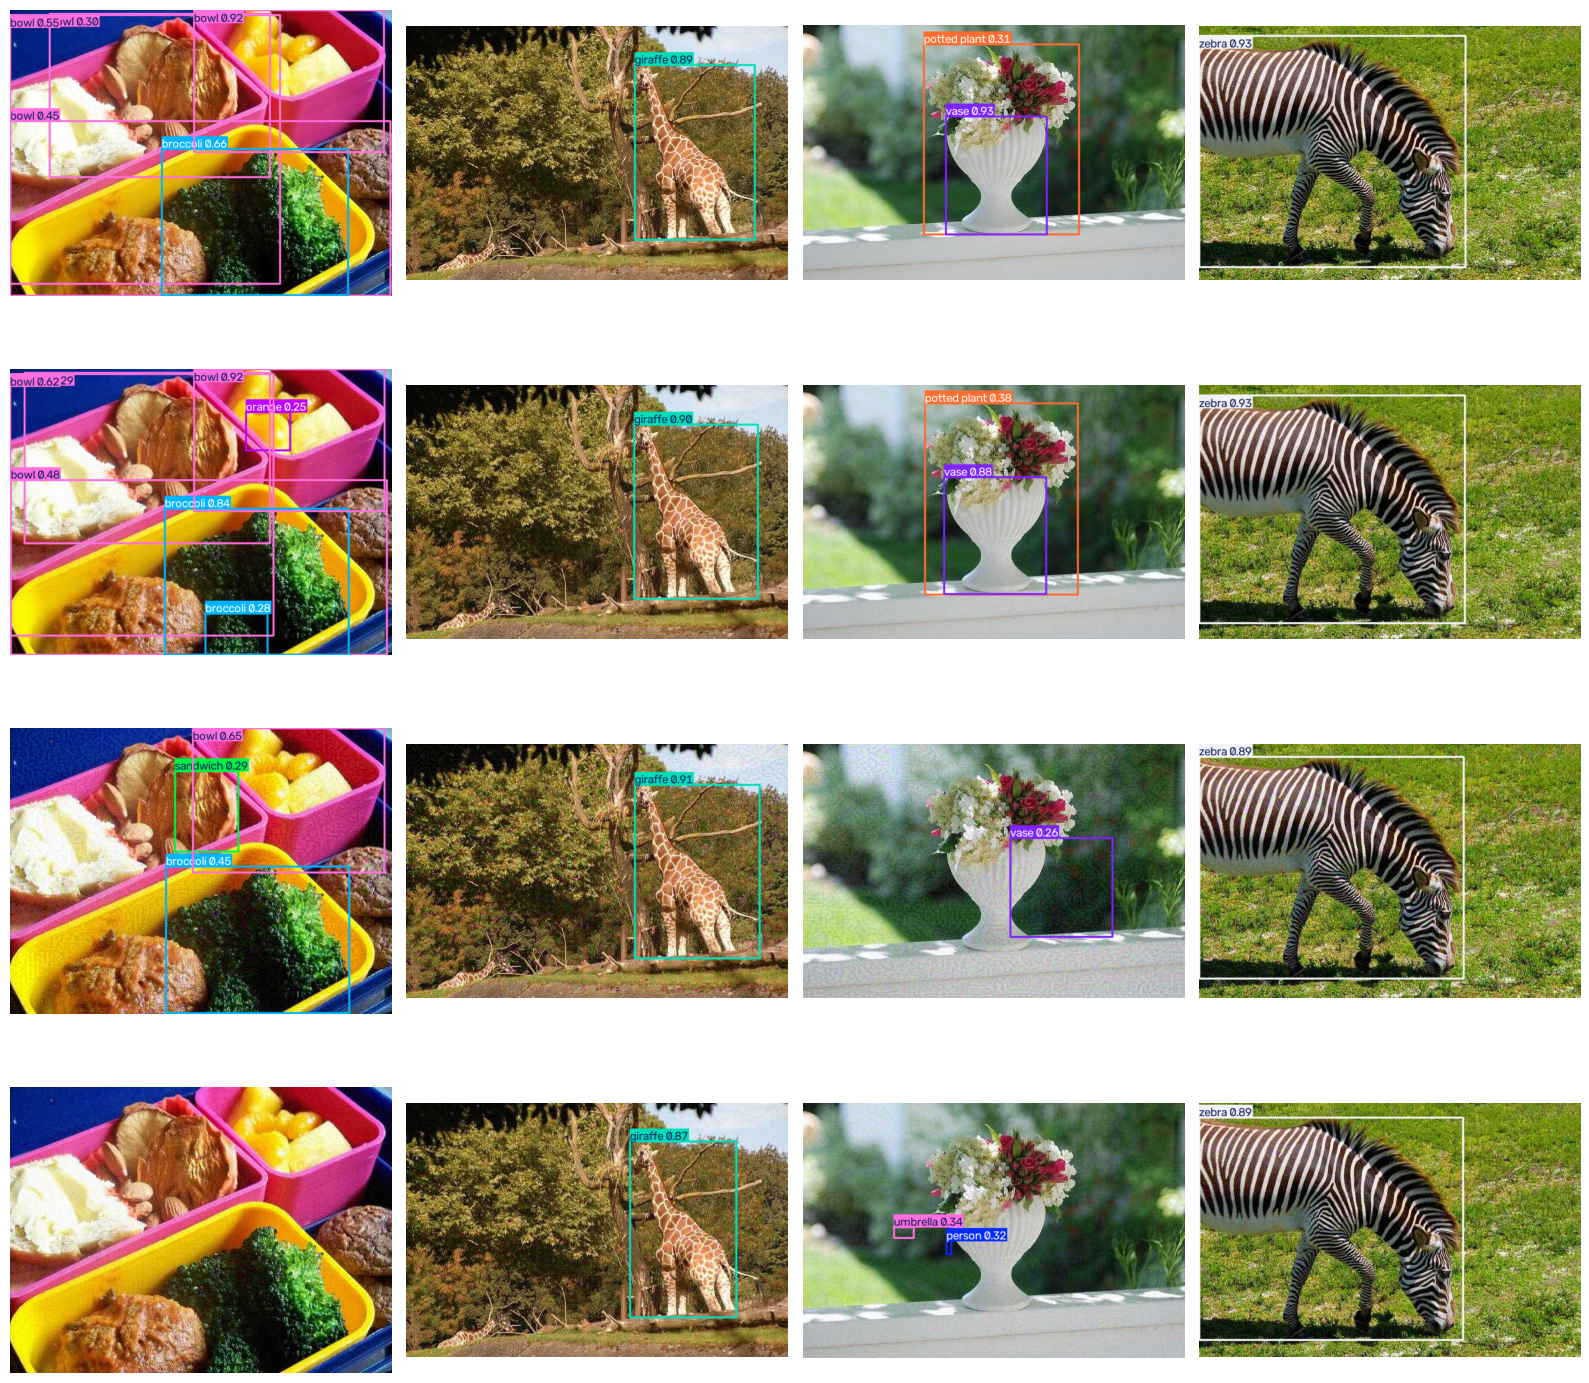

In [9]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

def run_all_attacks_slider(epsilon_val):
    # Efface proprement la sortie précédente pour éviter l'empilement
    clear_output(wait=True)

    # Réaffiche le titre pour qu'il reste fixe au-dessus du curseur
    display(HTML("<h3 style='color: #2b5b84;'>🔥 Comparatif Avancé : Bruit vs FGSM vs PGD</h3>"))
    display(epsilon_slider)  # Réaffiche le curseur pour qu'il ne disparaisse pas

    print(f"⚙️ Calcul en cours pour ε = {epsilon_val:.2f}...")

    num_samples = min(4, len(image_paths))
    fig, axes = plt.subplots(4, num_samples, figsize=(16, 15))

    for idx in range(num_samples):
        img_path = image_paths[idx]
        raw_image = Image.open(img_path).convert("RGB")
        original_size = raw_image.size

        # 1. Original
        orig_results = model(raw_image, verbose=False)[0]
        axes[0, idx].imshow(cv2.cvtColor(orig_results.plot(), cv2.COLOR_BGR2RGB))
        axes[0, idx].axis("off")
        if idx == 0: axes[0, idx].set_ylabel("Originale", fontsize=11, fontweight='bold')

        # 2. Bruit Blanc
        input_tensor = preprocess(raw_image).unsqueeze(0).to(device)
        noise = (torch.rand_like(input_tensor) * 2 - 1) * epsilon_val
        white_noise_tensor = torch.clamp(input_tensor + noise, 0, 1)
        white_pil = transforms.ToPILImage()(white_noise_tensor.squeeze(0).cpu()).resize(original_size)
        white_results = model(white_pil, verbose=False)[0]
        axes[1, idx].imshow(cv2.cvtColor(white_results.plot(), cv2.COLOR_BGR2RGB))
        axes[1, idx].axis("off")
        if idx == 0: axes[1, idx].set_ylabel(f"Bruit Blanc\n(eps={epsilon_val:.2f})", fontsize=11, fontweight='bold')

        # 3. FGSM
        adv_fgsm = fgsm_attack_yolo(model, img_path, epsilon=epsilon_val)
        fgsm_results = model(adv_fgsm, verbose=False)[0]
        axes[2, idx].imshow(cv2.cvtColor(fgsm_results.plot(), cv2.COLOR_BGR2RGB))
        axes[2, idx].axis("off")
        if idx == 0: axes[2, idx].set_ylabel(f"FGSM (1 pas)\n(eps={epsilon_val:.2f})", fontsize=11, fontweight='bold')

        # 4. PGD (Itératif)
        adv_pgd = pgd_attack_yolo(model, img_path, epsilon=epsilon_val, alpha=epsilon_val/4, num_iter=10)
        pgd_results = model(adv_pgd, verbose=False)[0]
        axes[3, idx].imshow(cv2.cvtColor(pgd_results.plot(), cv2.COLOR_BGR2RGB))
        axes[3, idx].axis("off")
        if idx == 0: axes[3, idx].set_ylabel(f"PGD (10 iters)\n(eps={epsilon_val:.2f})", fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Création du curseur
epsilon_slider = widgets.FloatSlider(
    min=0.0,
    max=0.2,
    step=0.01,
    value=0.04,
    description='Epsilon (ε):',
    style={'description_width': 'initial', 'handle_color': '#d9534f'},
    layout=widgets.Layout(width='450px')
)

# L'interaction observe le changement de valeur du curseur
epsilon_slider.observe(lambda change: run_all_attacks_slider(change['new']), names='value')

# Affichage initial
display(HTML("<h3 style='color: #2b5b84;'>🔥 Comparatif Avancé : Bruit vs FGSM vs PGD</h3>"))
display(epsilon_slider)
run_all_attacks_slider(epsilon_slider.value)